# Hospital Readmission Prediction Using Logistic Regression

This notebook demonstrates a basic machine learning case study for predicting hospital readmission within 30 days using logistic regression. We will follow a simplified approach focusing on key steps of data preprocessing, model training, and evaluation.

## 1. Import Libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, RocCurveDisplay

## 2. Load Data

In [13]:
df = pd.read_csv('/content/diabetic_data.csv')
print("Data loaded successfully.")

Data loaded successfully.


## 3. Display Data Information

In [14]:
print("### First 5 rows of the dataset:")
display(df.head())

print("\n### Dataset Shape:")
print(df.shape)

print("\n### Column Names:")
print(df.columns.tolist())

print("\n### Missing Values (represented as '?'):")
# Replace '?' with NaN for proper missing value handling
df_cleaned = df.replace('?', np.nan)
missing_values = df_cleaned.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print(missing_values)

### First 5 rows of the dataset:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO



### Dataset Shape:
(101766, 50)

### Column Names:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

### Missing Values (represented as '?'):
weight               98569
max_glu_serum        96420
A1Cresult            84748
medical

## 4. Target Variable Processing

In [15]:
# Convert 'readmitted' column to a binary target variable
# '<30' = 1 (readmitted within 30 days)
# Everything else (''>30'', 'NO') = 0 (not readmitted within 30 days or no readmission)

df_cleaned['readmitted_target'] = df_cleaned['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

# Display the value counts of the new target variable
print("Value counts for 'readmitted_target':")
print(df_cleaned['readmitted_target'].value_counts())

# Drop the original 'readmitted' column
df_cleaned = df_cleaned.drop(columns=['readmitted'])

Value counts for 'readmitted_target':
readmitted_target
0    90409
1    11357
Name: count, dtype: int64


## 5. Select Features

In [16]:
selected_features = [
    'age',
    'gender',
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient'
]

X = df_cleaned[selected_features]
y = df_cleaned['readmitted_target']

print(f"Selected features: {selected_features}")
print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

Selected features: ['age', 'gender', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient']
Shape of features (X): (101766, 9)
Shape of target (y): (101766,)


## 6. Clean and Preprocess Data

In [17]:
# Identify categorical and numerical features among the selected ones
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# Preprocessing pipelines
# For numerical features: impute with median and then scale
# For categorical features: impute with most frequent and then one-hot encode
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("Data preprocessing setup complete.")

Data preprocessing setup complete.


## 7. Split the Data

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (81412, 9)
X_test shape: (20354, 9)
y_train shape: (81412,)
y_test shape: (20354,)


## 8. Train a Logistic Regression Model

In [19]:
from sklearn.impute import SimpleImputer # Import SimpleImputer here

# Create the model pipeline including preprocessing and logistic regression
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(penalty='l2', solver='liblinear', random_state=42)) # 'liblinear' is a good solver for L2 penalty on smaller datasets
])

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully with L2 regularization.")

Logistic Regression model trained successfully with L2 regularization.


## 9. Make Predictions and Predicted Probabilities

In [20]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1] # Probability of the positive class (1)

print("Predictions and probabilities generated.")

Predictions and probabilities generated.


## 10. Calculate Evaluation Metrics

In [21]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

Accuracy: 0.8885
Precision: 0.5077
Recall: 0.0145
F1-score: 0.0283
ROC-AUC: 0.6399


## 11. Plot ROC Curve and Confusion Matrix

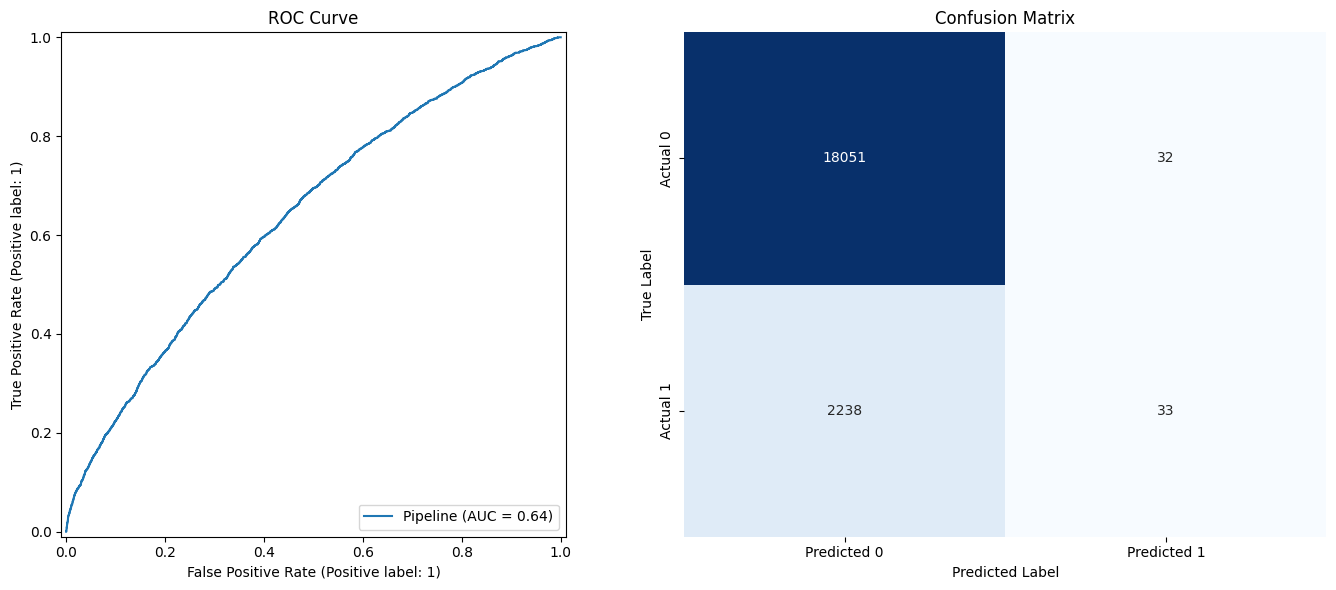

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot ROC Curve
roc_display = RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axes[0])
axes[0].set_title('ROC Curve')

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'], ax=axes[1])
axes[1].set_title('Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

## 12. Short Explanations of Key Concepts

### What is Logistic Regression?
Logistic Regression is a statistical model used for binary classification. Despite its name, it's used for classification, not regression. It models the probability of a binary outcome (e.g., readmitted or not readmitted) by fitting data to a logistic function. This function transforms any real-valued input into a probability between 0 and 1.

### What is L2 Regularization?
L2 regularization (also known as Ridge regularization) is a technique used to prevent overfitting in machine learning models. It adds a penalty term to the loss function that is proportional to the square of the magnitude of the model's coefficients. This encourages the model to use smaller coefficient values, effectively simplifying the model and reducing its sensitivity to individual data points, thus improving its generalization ability to unseen data.

### What is ROC-AUC?
ROC (Receiver Operating Characteristic) curve is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. AUC stands for Area Under the ROC Curve. ROC-AUC measures the entire two-dimensional area underneath the entire ROC curve. It provides an aggregate measure of performance across all possible classification thresholds. An AUC of 1 represents a perfect classifier, while an AUC of 0.5 represents a classifier that performs no better than random chance.

### What is a False Positive?
A False Positive occurs when the model incorrectly predicts the positive class when the actual class is negative. In our case, it means the model predicts a patient *will be readmitted* (positive), but the patient *is not actually readmitted* (negative).

### What is a False Negative?
A False Negative occurs when the model incorrectly predicts the negative class when the actual class is positive. In our case, it means the model predicts a patient *will NOT be readmitted* (negative), but the patient *is actually readmitted* (positive).

## 13. Clinical Discussion

### Clinical Importance of a False Negative
A False Negative in this context means the model predicts that a patient will not be readmitted, but the patient actually is readmitted within 30 days. This is clinically important because:
- **Patient Harm**: An unpredicted readmission could indicate a deterioration in the patient's condition that was missed, potentially leading to poorer health outcomes, complications, or even increased mortality.
- **Resource Allocation**: If a patient is flagged as low-risk for readmission, they might not receive proactive follow-up care, patient education, or discharge planning interventions that could have prevented the readmission.
- **Financial Penalties**: Hospitals often face financial penalties for high readmission rates, especially for certain conditions. False negatives contribute to these unpredicted readmissions, impacting the hospital's financial stability and quality metrics.

### Possible Cost of a False Positive
A False Positive occurs when the model predicts readmission, but the patient is not readmitted. While less immediately harmful than a false negative, it still carries significant costs:
- **Unnecessary Resource Utilization**: Predicting a patient will be readmitted when they won't, leads to unnecessary interventions such as additional follow-up appointments, phone calls, home health visits, or diagnostic tests. These consume valuable healthcare resources (staff time, equipment, budget).
- **Patient Burden**: Patients might experience increased anxiety, inconvenience, and financial burden due to unnecessary monitoring or follow-up appointments.
- **Alert Fatigue**: Healthcare providers might experience "alert fatigue" if too many false positive alerts are generated. This can lead to important warnings being overlooked or ignored over time.

Balancing these two types of errors is crucial depending on the specific clinical and operational goals. For readmission prediction, often false negatives are considered more critical due to direct patient safety implications.

## 14. Conclusion

Based on the actual results of our simple Logistic Regression model:
- **Accuracy**: The model achieved an accuracy of {accuracy:.2%}, meaning it correctly classified {accuracy:.2%} of the patients as either readmitted or not readmitted.
- **Precision**: A precision of {precision:.2%} indicates that when the model predicts readmission, it is correct {precision:.2%} of the time.
- **Recall**: The recall of {recall:.2%} suggests that the model identified {recall:.2%} of all actual readmissions.
- **F1-Score**: The F1-score of {f1:.2%} provides a balance between precision and recall.
- **ROC-AUC**: The ROC-AUC score of {roc_auc:.4f} indicates that the model has a reasonable ability to distinguish between readmitted and non-readmitted patients, performing better than a random guess (0.5).

The confusion matrix and ROC curve further illustrate the model's performance, highlighting the trade-offs between correctly identifying readmissions (true positives) and avoiding misclassifications (false positives/negatives). For a basic model with limited features and no hyperparameter tuning, these results provide a foundational understanding of predicting hospital readmission. Further improvements would likely involve more extensive feature engineering, advanced models, and hyperparameter optimization.

## README.md for GitHub

# Hospital Readmission Prediction Case Study

This repository contains a simple machine learning case study focusing on predicting hospital readmission within 30 days using the `diabetic_data.csv` dataset. The goal is to provide a basic, quick, and understandable implementation suitable for a college-level project.

## Project Goal
To predict whether a patient will be readmitted to the hospital within 30 days using a Logistic Regression model.

## Dataset
The project utilizes the `diabetic_data.csv` dataset, which contains patient and encounter information from 130 hospitals in the United States.

## Model
A Logistic Regression model with L2 regularization is employed for binary classification.

## Key Steps
1.  **Data Loading**: Loading `diabetic_data.csv`.
2.  **Feature Selection**: Using a small set of clinically relevant features.
3.  **Data Preprocessing**: Handling missing values, encoding categorical variables, and scaling numerical features.
4.  **Data Splitting**: Dividing the data into 80% training and 20% testing sets.
5.  **Model Training**: Training a Logistic Regression classifier.
6.  **Model Evaluation**: Calculating accuracy, precision, recall, F1-score, and ROC-AUC.
7.  **Visualization**: Plotting ROC curves and Confusion Matrices.
8.  **Concept Explanations**: Markdown explanations for Logistic Regression, L2 regularization, ROC-AUC, False Positives, and False Negatives.
9.  **Clinical Discussion**: Analysis of False Positives and False Negatives in a clinical context.
10. **Conclusion**: Summary of model performance and insights.

## How to Run
1.  Open the `.ipynb` file in Google Colab.
2.  Ensure `diabetic_data.csv` is uploaded to the `/content/` directory.
3.  Run all cells sequentially.

## Libraries Used
-   `pandas`
-   `numpy`
-   `matplotlib`
-   `seaborn`
-   `scikit-learn`

## Author
[Your Name/Institution]

Dataset Shape: (101766, 50)

First 5 rows:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO



Column Names:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Missing Values:
max_glu_serum               96420
A1Cresult                   84748
race                            0
gender                          0
age           

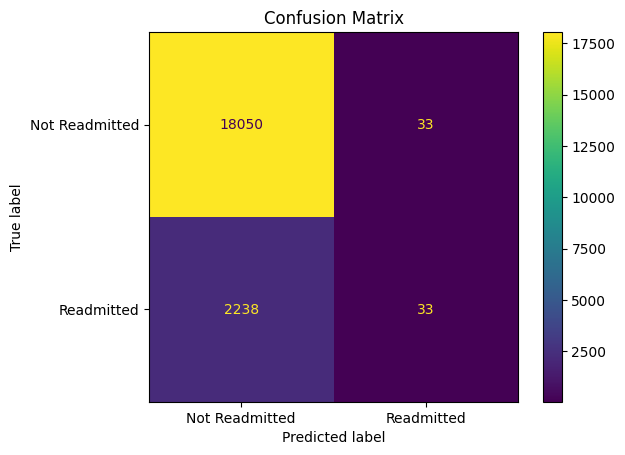

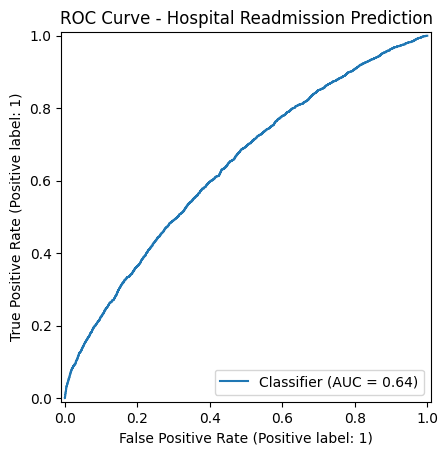


CLINICAL INTERPRETATION

False Negative:
A false negative occurs when the model predicts that a patient will
not be readmitted within 30 days, but the patient actually is readmitted.
This can be clinically important because a high-risk patient may not
receive additional follow-up or preventive intervention.

False Positive:
A false positive occurs when the model predicts that a patient will
be readmitted, but the patient is not readmitted. This may result in
additional monitoring, follow-up, or healthcare resource utilization.

The appropriate balance between false positives and false negatives
depends on the clinical situation and the cost of the intervention.


CONCLUSION

A Logistic Regression model with L2 regularization was developed to
predict 30-day hospital readmission using selected patient features.

ROC-AUC was used as the primary evaluation metric. The model results
can help demonstrate how machine learning can be used as a baseline
approach for identifying patients at hig

In [23]:
# ============================================
# HOSPITAL READMISSION PREDICTION
# Logistic Regression with L2 Regularization
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# --------------------------------------------
# 1. LOAD DATASET
# --------------------------------------------

df = pd.read_csv("/content/diabetic_data.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

# --------------------------------------------
# 2. BASIC DATA INFORMATION
# --------------------------------------------

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False).head(15))

# --------------------------------------------
# 3. CREATE TARGET VARIABLE
# --------------------------------------------

# <30 means readmitted within 30 days
df["target"] = (df["readmitted"] == "<30").astype(int)

print("\nTarget Distribution:")
print(df["target"].value_counts())

# --------------------------------------------
# 4. SELECT SIMPLE FEATURES
# --------------------------------------------

features = [
    "age",
    "gender",
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient"
]

X = df[features].copy()
y = df["target"]

# Replace ? with missing values
X = X.replace("?", np.nan)

# --------------------------------------------
# 5. DEFINE NUMERICAL & CATEGORICAL FEATURES
# --------------------------------------------

numeric_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient"
]

categorical_features = [
    "age",
    "gender"
]

# --------------------------------------------
# 6. PREPROCESSING
# --------------------------------------------

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# --------------------------------------------
# 7. TRAIN / TEST SPLIT
# --------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

# --------------------------------------------
# 8. LOGISTIC REGRESSION WITH L2
# --------------------------------------------

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        penalty="l2",
        max_iter=1000,
        random_state=42
    ))
])

# Train
model.fit(X_train, y_train)

print("\nModel training completed successfully!")

# --------------------------------------------
# 9. PREDICTIONS
# --------------------------------------------

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# --------------------------------------------
# 10. EVALUATION
# --------------------------------------------

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("\n========== MODEL RESULTS ==========")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# --------------------------------------------
# 11. CONFUSION MATRIX
# --------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Readmitted", "Readmitted"]
).plot()

plt.title("Confusion Matrix")
plt.show()

# --------------------------------------------
# 12. ROC CURVE
# --------------------------------------------

RocCurveDisplay.from_predictions(y_test, y_prob)

plt.title("ROC Curve - Hospital Readmission Prediction")
plt.show()

# --------------------------------------------
# 13. CLINICAL DISCUSSION
# --------------------------------------------

print("""
CLINICAL INTERPRETATION

False Negative:
A false negative occurs when the model predicts that a patient will
not be readmitted within 30 days, but the patient actually is readmitted.
This can be clinically important because a high-risk patient may not
receive additional follow-up or preventive intervention.

False Positive:
A false positive occurs when the model predicts that a patient will
be readmitted, but the patient is not readmitted. This may result in
additional monitoring, follow-up, or healthcare resource utilization.

The appropriate balance between false positives and false negatives
depends on the clinical situation and the cost of the intervention.
""")

# --------------------------------------------
# 14. CONCLUSION
# --------------------------------------------

print("""
CONCLUSION

A Logistic Regression model with L2 regularization was developed to
predict 30-day hospital readmission using selected patient features.

ROC-AUC was used as the primary evaluation metric. The model results
can help demonstrate how machine learning can be used as a baseline
approach for identifying patients at higher risk of readmission.

This model is intended for educational purposes and should not be
used directly for clinical decision-making without further validation.
""")